# 04. Analysis RQ2: Content & Sentiment Analysis (内容与情感分析)

**Research Question:** Do specific narrative elements (based on Overview NLP) correlate with higher Ratings or Revenue?
**核心问题:** “叫好”与“叫座”是否矛盾？基于简介的NLP分析，哪类叙事元素的电影更容易获得高票房或高评分？

**Steps:**
1. Load Data & Preprocessing (加载数据与预处理)
2. Keyword Extraction (关键词提取)
3. Sentiment Analysis (情感分析)
4. Correlation Analysis (相关性分析)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import string

# Ensure NLTK resources are available
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')
    
try:
    nltk.data.find('corpora/stopwords.zip')
except LookupError:
    nltk.download('stopwords')

sns.set(style="whitegrid")

# Load Processed Data
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
df = pd.read_csv(PROCESSED_DATA_PATH)

# Drop rows with missing overview
df = df.dropna(subset=['overview'])

print(f"Data Loaded: {df.shape}")
display(df[['title', 'overview', 'revenue', 'vote_average']].head(2))

ModuleNotFoundError: No module named 'wordcloud'

## 2. Keyword Extraction (关键词提取)
We visualize the most frequent words in successful movies (High Revenue) vs. highly rated movies (High Rating).

Generating WordCloud for High Revenue Movies...


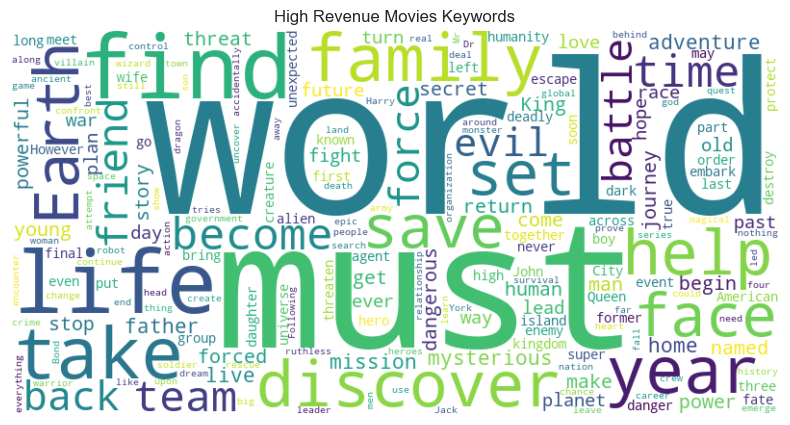

Generating WordCloud for High Rated Movies...


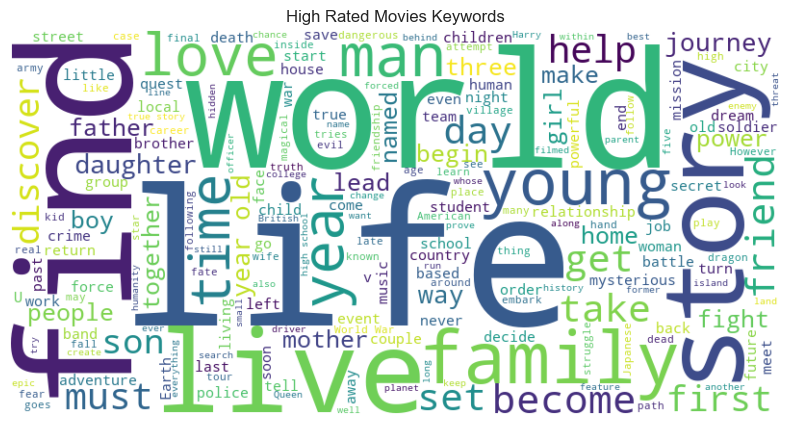

In [ ]:
def generate_wordcloud(text_data, title):
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords if necessary
    stop_words.update(['movie', 'film', 'one', 'two', 'new'])
    
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          stopwords=stop_words,
                          min_font_size=10).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Top 10% Revenue Movies
high_revenue_df = df[df['revenue'] > df['revenue'].quantile(0.90)]
text_revenue = " ".join(high_revenue_df['overview'].astype(str))

print("Generating WordCloud for High Revenue Movies...")
generate_wordcloud(text_revenue, "High Revenue Movies Keywords")

# Top 10% Rated Movies
high_rating_df = df[df['vote_average'] > df['vote_average'].quantile(0.90)]
text_rating = " ".join(high_rating_df['overview'].astype(str))

print("Generating WordCloud for High Rated Movies...")
generate_wordcloud(text_rating, "High Rated Movies Keywords")

## 3. Sentiment Analysis (情感分析)
Using NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner) to compute a compound sentiment score for each overview.
- **Compound Score**: -1 (Most Negative) to +1 (Most Positive)

In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(str(text))['compound']

print("Calculating sentiment scores (this may take a moment)...")
df['sentiment_score'] = df['overview'].apply(get_sentiment)

print("Sentiment Analysis Complete.")
display(df[['title', 'overview', 'sentiment_score']].head())

Calculating sentiment scores (this may take a moment)...


Sentiment Analysis Complete.


,title,overview,sentiment_score
0,Inception,"Cobb, a skilled thief who commits corporate es...",-0.3182
1,Interstellar,The adventures of a group of explorers who mak...,0.3400
2,The Dark Knight,Batman raises the stakes in his war on crime. ...,-0.9607
3,Avatar,"In the 22nd century, a paraplegic Marine is di...",-0.3612
4,The Avengers,When an unexpected enemy emerges and threatens...,-0.6696


## 4. Correlation Analysis (相关性分析)
Does a positive or negative overview correlate with higher revenue or ratings?

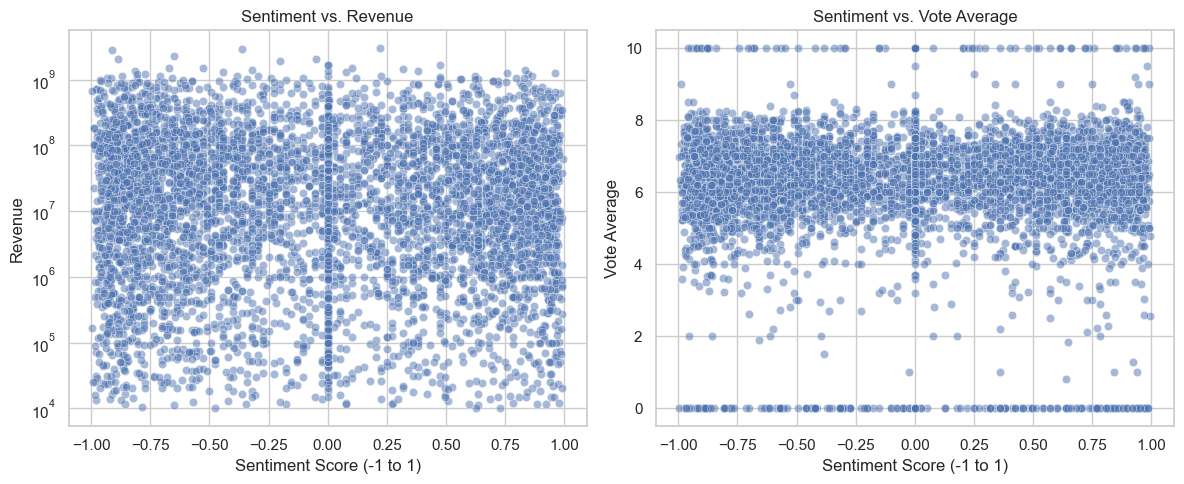

Correlation Matrix:


,sentiment_score,revenue,vote_average,budget
sentiment_score,1.000000,-0.036212,-0.025078,-0.041189
revenue,-0.036212,1.000000,0.135943,0.769179
vote_average,-0.025078,0.135943,1.000000,0.125085
budget,-0.041189,0.769179,0.125085,1.000000


In [ ]:
plt.figure(figsize=(12, 5))

# Sentiment vs Revenue
plt.subplot(1, 2, 1)
sns.scatterplot(x='sentiment_score', y='revenue', data=df, alpha=0.5)
plt.title('Sentiment vs. Revenue')
plt.xlabel('Sentiment Score (-1 to 1)')
plt.ylabel('Revenue')
plt.yscale('log')  # Log scale for revenue

# Sentiment vs Rating
plt.subplot(1, 2, 2)
sns.scatterplot(x='sentiment_score', y='vote_average', data=df, alpha=0.5)
plt.title('Sentiment vs. Vote Average')
plt.xlabel('Sentiment Score (-1 to 1)')
plt.ylabel('Vote Average')

plt.tight_layout()
plt.show()

# Correlation Matrix
corr = df[['sentiment_score', 'revenue', 'vote_average', 'budget']].corr()
print("Correlation Matrix:")
display(corr)